In [1]:
!pip install lime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss
from tensorflow import keras
from tensorflow.keras import layers
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
import warnings
warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=105145e82623d1c7cd3b13bf16557e2b7c098ee2352abc64743cd2d9d4bb2a5f
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [2]:
df = pd.read_csv("email.csv")
df

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...
...,...,...,...,...,...,...,...,...,...,...,...
48456,{U3G0-Y9SO51JU-4612XCYA},01/11/2010 16:46:26,FUM0015,PC-9208,Frances.Alisa.Wiggins@dtaa.com;Halla.Cathleen....,NaN,NaN,Fatima.Ulla.Mcclure@dtaa.com,24043,1,three can begins trouble rebellion potentially...
48457,{X0L8-A7GE70KW-5923FABJ},01/11/2010 16:46:29,DRR0242,PC-5002,Vance.Ira.Alston@dtaa.com;Amaya.Britanni.Newto...,Prescott.Giacomo.Conley@dtaa.com,Daphne.Ruby.Reilly@dtaa.com,Daphne.Ruby.Reilly@dtaa.com,40173,0,beorhtfrith combines ships twenty east britain...
48458,{O5K9-Q9PQ90MI-0605WIHI},01/11/2010 16:46:32,QPM0727,PC-3406,Cassady.Quincy.Hampton@dtaa.com;Maxwell.Hammet...,Finn.Tucker.Medina@dtaa.com,NaN,Quincy.Preston.Moses@dtaa.com,33860,0,three concluded final dissolves included revie...
48459,{J0V0-N5KF31PI-6244ITFS},01/11/2010 16:46:36,SER0165,PC-7309,Winter.Veda.Burks@dtaa.com,NaN,NaN,Stephanie.Eliana.Rasmussen@dtaa.com,31723,0,extends embarked manage aware disaster trying ...


In [4]:
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48461 entries, 0 to 48460
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           48461 non-null  object
 1   date         48461 non-null  object
 2   user         48461 non-null  object
 3   pc           48461 non-null  object
 4   to           48461 non-null  object
 5   cc           21851 non-null  object
 6   bcc          8306 non-null   object
 7   from         48461 non-null  object
 8   size         48461 non-null  int64 
 9   attachments  48461 non-null  int64 
 10  content      48461 non-null  object
dtypes: int64(2), object(9)
memory usage: 4.1+ MB
None


In [5]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Fill missing vals
df.fillna('', inplace=True)

In [6]:
le = LabelEncoder()
for col in ['user', 'pc', 'to', 'cc', 'bcc', 'from']:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,588,553,5649,5390,0,1223,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,675,665,16624,0,0,1241,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,588,553,17126,0,0,1224,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,588,553,11763,0,0,1224,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,675,665,2705,0,429,1241,17319,0,this kmh october holliswood number advised unu...


In [7]:
# Feature Engineering from 'date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# feature selection
df.drop(columns=['date', 'to', 'cc', 'from'], inplace=True)


In [8]:
# Create a label based on 'bcc' and 'size' as suspicious
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['size'] = df['size'].fillna(0)
df['is_malicious'] = ((df['bcc'].astype(str).astype(int) > 0) & (df['size'] > 50000)).astype(int)

print(df['is_malicious'].value_counts())

is_malicious
0    48108
1      353
Name: count, dtype: int64


In [9]:
features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
features.remove('is_malicious')

X = df[features]
y = df['is_malicious']

EDA

In [10]:
# Handle outliers using Z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).all(axis=1)  # Identify outliers (Z-score > 3)
print(f"Number of outlier rows: {outliers.sum()}")



Number of outlier rows: 0


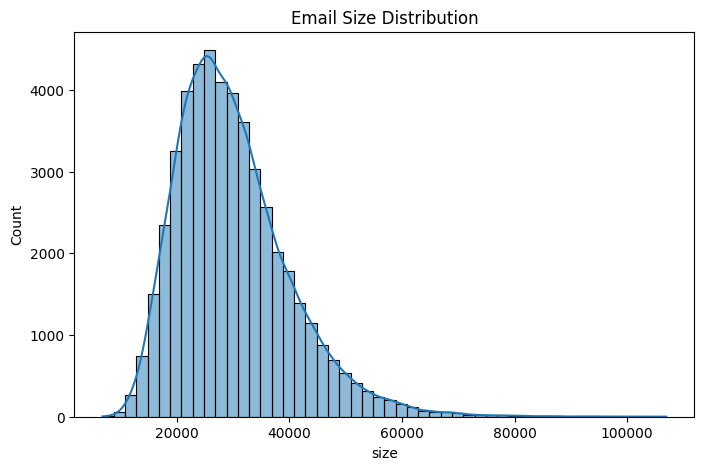

In [11]:
#size dist
plt.figure(figsize=(8,5))
sns.histplot(df['size'], bins=50, kde=True)
plt.title("Email Size Distribution")
plt.show()


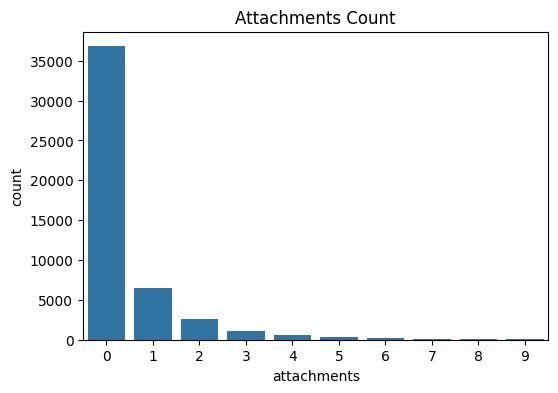

In [12]:
#Num ofattachments
plt.figure(figsize=(6,4))
sns.countplot(x='attachments', data=df)
plt.title("Attachments Count")
plt.show()


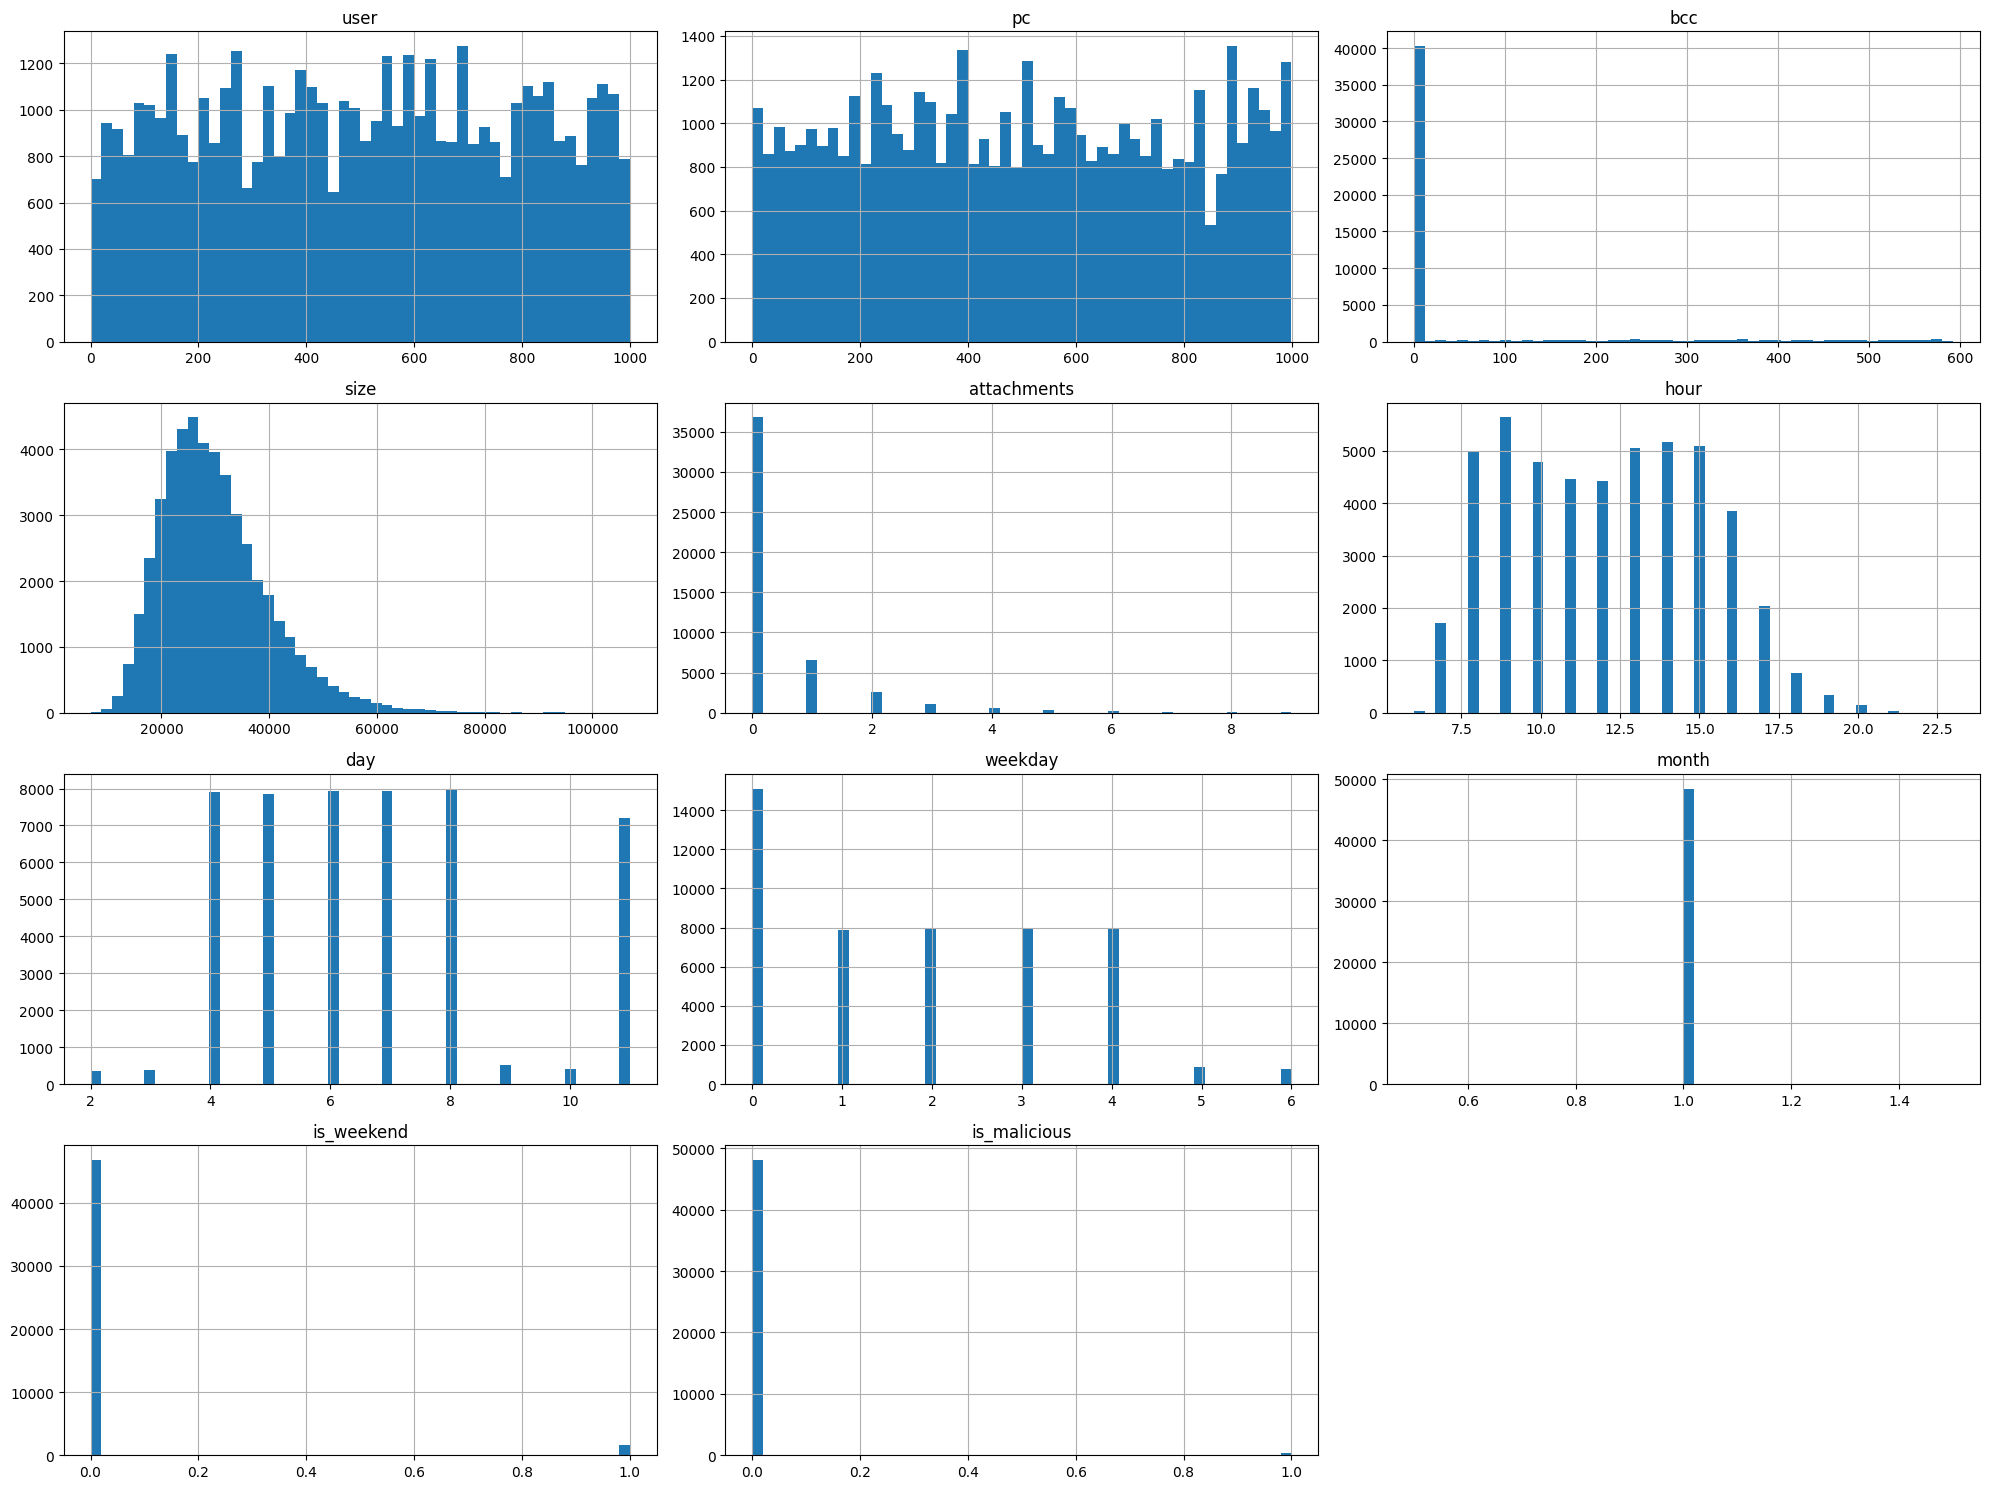

In [13]:
df.hist(figsize=(20, 15), bins=50)
plt.tight_layout()
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

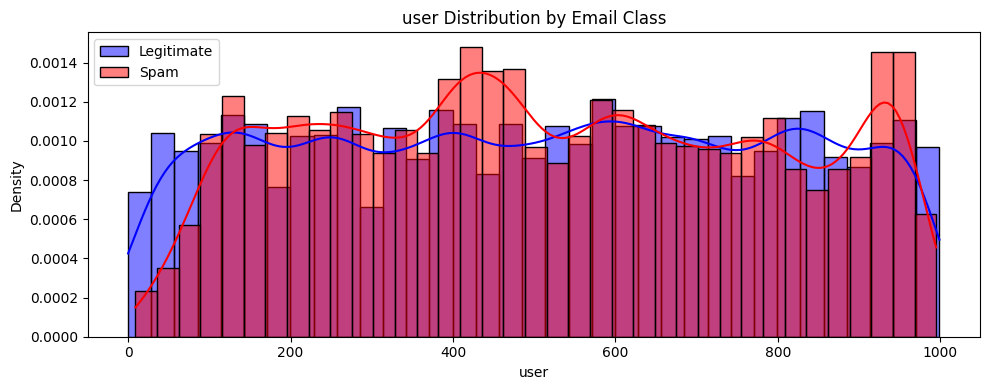

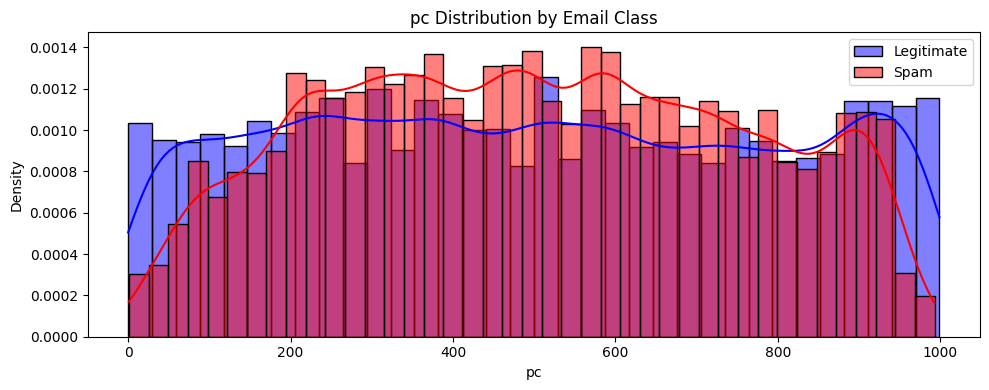

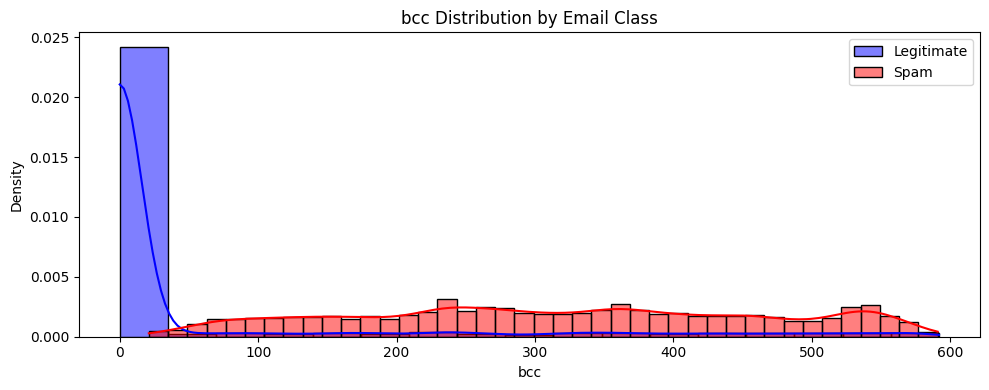

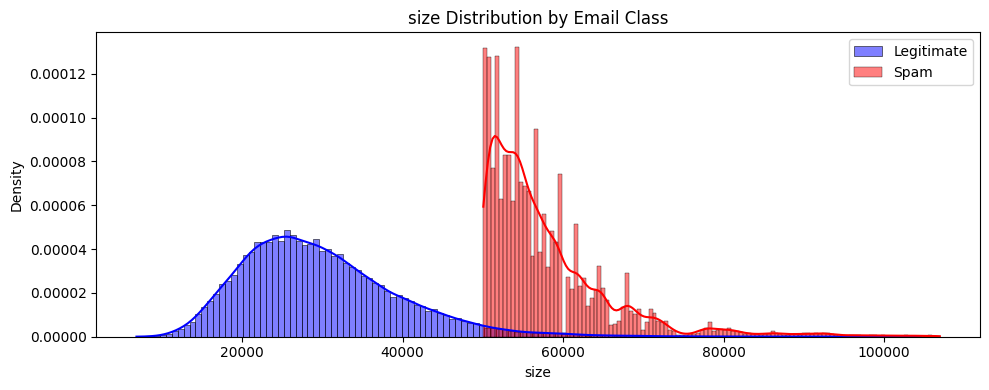

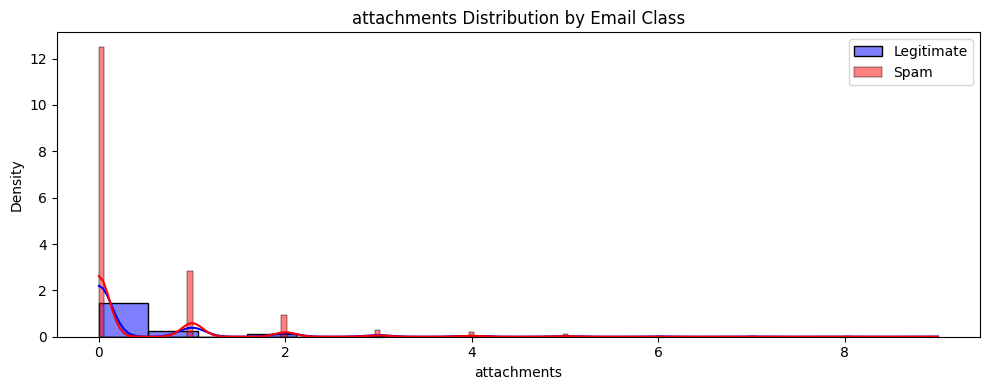

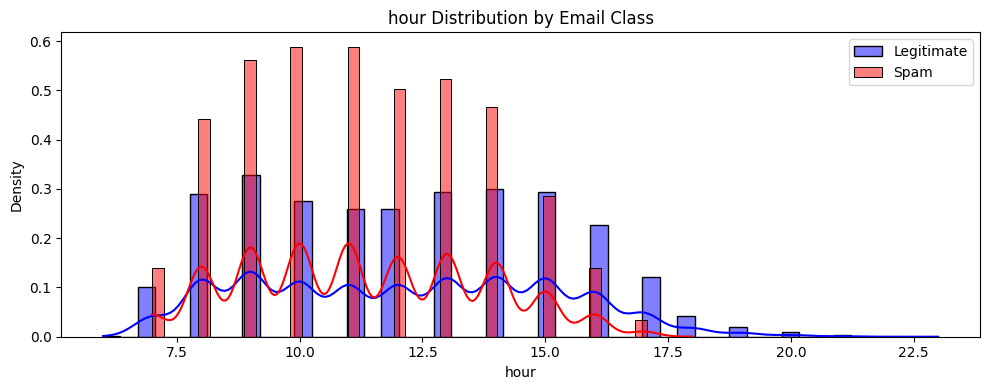

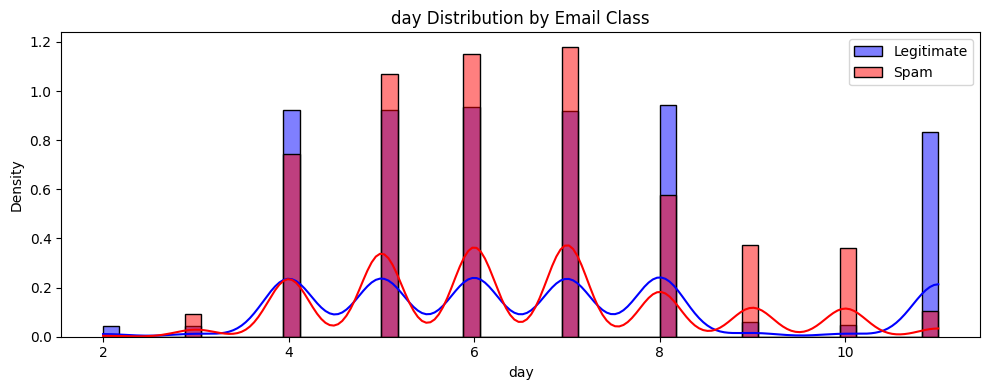

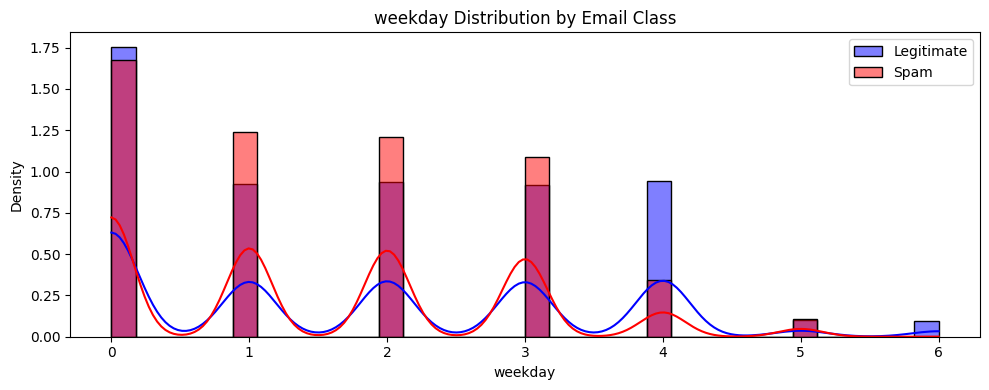

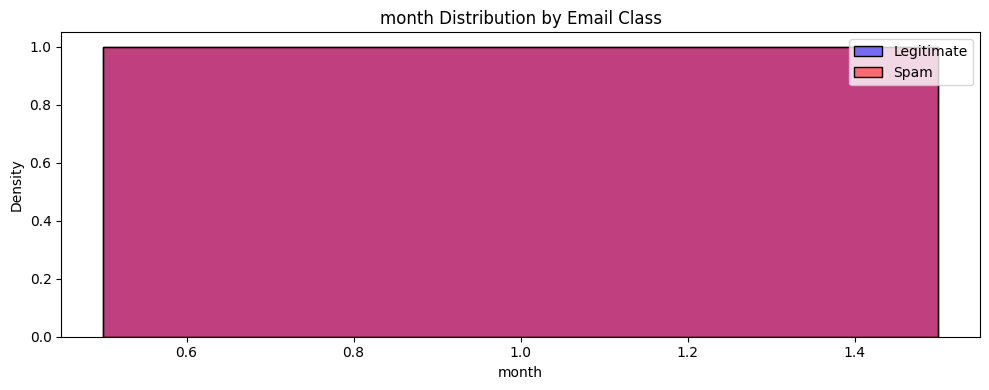

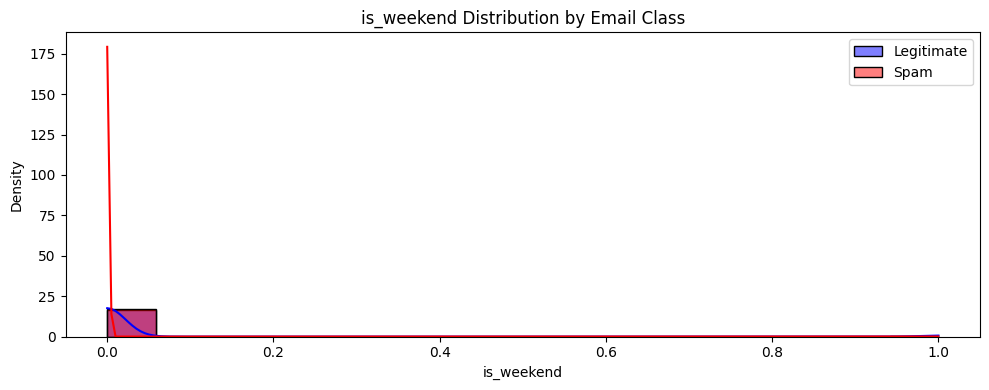

In [16]:
for feature in X_resampled.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(X_resampled[feature][y_resampled == 0], color="blue", label="Legitimate", kde=True, stat="density")
    sns.histplot(X_resampled[feature][y_resampled == 1], color="red", label="Spam", kde=True, stat="density")
    plt.title(f'{feature} Distribution by Email Class')
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


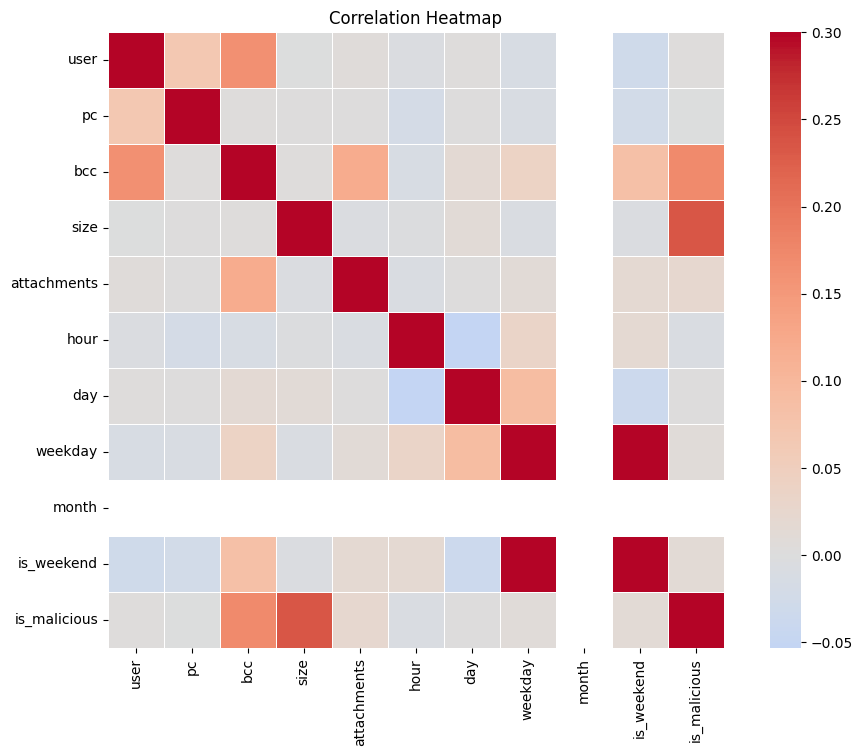

In [19]:
numeric_df = df.select_dtypes(include=['number', 'bool'])
if 'id' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['id'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', vmax=0.3, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


NAive Bayes Model

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

history = {'accuracy': cv_scores}

print(f"Cross-validation accuracy: {np.mean(cv_scores):.2f}")

Cross-validation accuracy: 0.99


In [22]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_test = y_test.astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

test_accuracy = model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

[[9548   70]
 [  29   46]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      9618
           1       0.40      0.61      0.48        75

    accuracy                           0.99      9693
   macro avg       0.70      0.80      0.74      9693
weighted avg       0.99      0.99      0.99      9693

Test Accuracy: 0.99


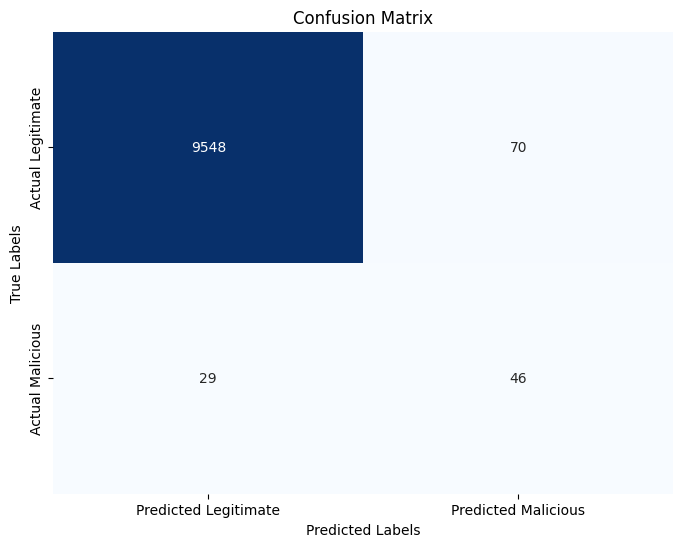

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Legitimate', 'Predicted Malicious'],
            yticklabels=['Actual Legitimate', 'Actual Malicious'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


LIME

In [36]:
import lime
import lime.lime_tabular
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train_scaled,
                                                   training_labels=y_train,
                                                   mode='classification',
                                                   feature_names=X.columns.tolist(),
                                                   class_names=np.unique(y).astype(str),
                                                   discretize_continuous=True)

idx = 31
exp = explainer.explain_instance(X_test_scaled[idx], model.predict_proba, num_features=10)
exp.show_in_notebook()

The model is 100% certain of class 0 and 0% certain of class 1, an extremely robust benign prediction. Decision is primarily made by principal feature thresholds: **attachment > -0.42**, **size (0.43) in 0.13–0.33 range**, and **age > 0.85**, the most influential of them. Secondary features like **day (1.87)**, **pc (1.45)**, and **hour (0.96)** met their conditions but were less influential. Features like **month (0.00)** and **weekday (-1.13)** did not contribute anything, as was the case with the previous analysis. Interestingly, **pec <= -0.39** and **weekday <= -1.13** were split features that benefited the model. It once again validates the observation that attachment, size, and age are significant predictors, and the other features add secondary importance to the model's decision. The findings align with the previous study, demonstrating the model's dependence on a subset of relevant features in a bid to classify accurately.

permutation_importance

In [41]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

y_pred_test = model.predict(X_test)

perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

sorted_idx = perm_result.importances_mean.argsort()

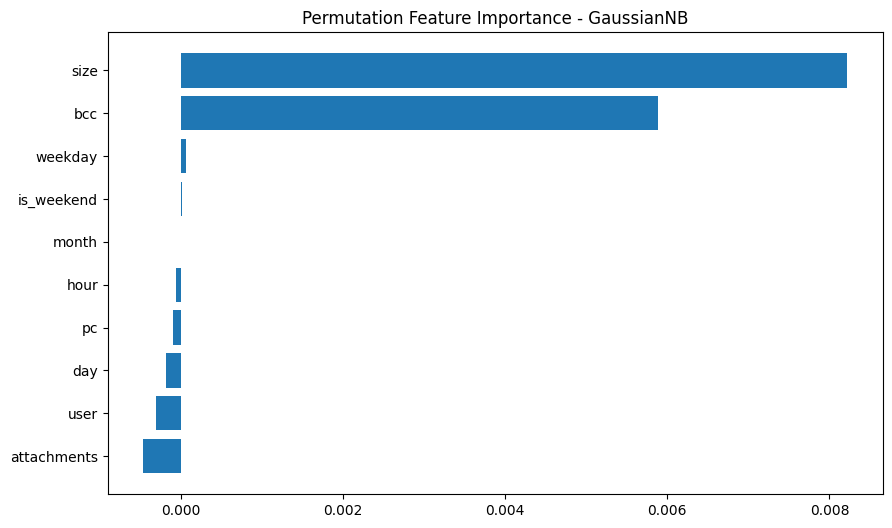

In [42]:
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), perm_result.importances_mean[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.title("Permutation Feature Importance - GaussianNB")
plt.show()

The permutation feature importance plot for the GaussianNB model illustrates the relative contribution of each feature towards making predictions. The most important variable is Size, followed by bcc, as permuting these values results in the largest loss of performance. The other temporal features such as weekday and is_weekend have little to no effect when permuted, meaning that they do not contribute much towards the decision-making of the model. The remaining attributes - hour, pc, and day - are weakly significant, their presence collectively making minimal impact on model performance. These findings augment prior feature importance analyses in consistently recognizing size and bcc as substantial predictive influences while affirming the supporting role of additional attributes. The results highlight the model's dependence on a small number of feature keys for successful classification, with the majority of attributes having minimal impact on predictive performance overall.

LOFO

In [43]:
baseline = cross_val_score(model, X_train, y_train, cv=5).mean()
lofo_scores = {}

for col in X_train.columns:
    X_lofo = X_train.drop(columns=[col])
    score = cross_val_score(model, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score

lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)

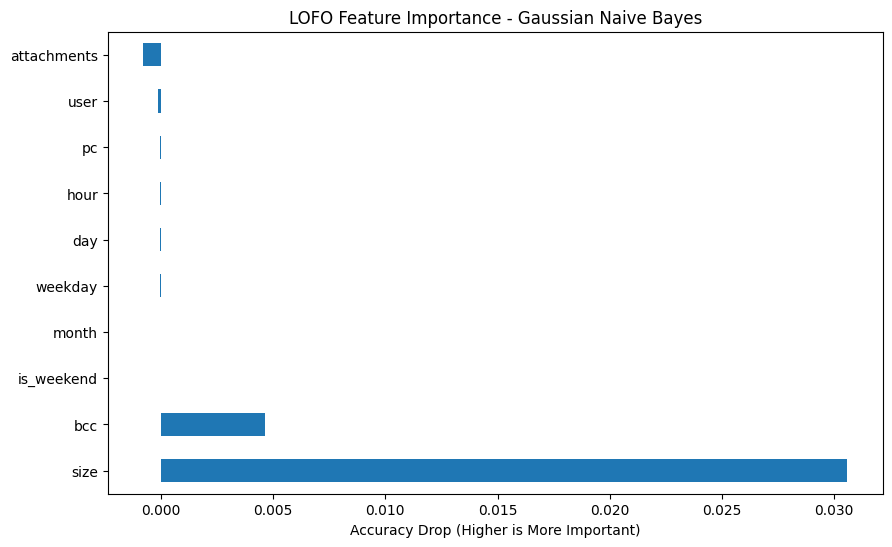

In [44]:
lofo_df.plot(kind='barh', figsize=(10, 6))
plt.title("LOFO Feature Importance - Gaussian Naive Bayes")
plt.xlabel("Accuracy Drop (Higher is More Important)")
plt.show()

LOFO feature importance for the Gaussian Naive Bayes model indicates size as most significant for prediction accuracy, followed by bcc since leaving out each of these features results in the highest decrease in model performance (range 0.020-0.030). On the other hand, at the opposite end, we have features attachments, user, and pc making little difference when left out, since their accuracy reductions are approximately zero. Temporal features (hour, day, weekday, month, is_weekend) are ranked in the middle, indicating small contributions. These findings confirm our previous results that size and bcc are the main drivers of the model, and most other features—and especially metadata features like attachments—are irrelevant. Agreement between LOFO, SHAP, and permutation methods increases trust in these feature importance rankings.



Global Surrogate Model

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

gnb_preds = model.predict(X_train)
surrogate = DecisionTreeClassifier(max_depth=3)
surrogate.fit(X_train, gnb_preds)

DecisionTreeClassifier(max_depth=3)

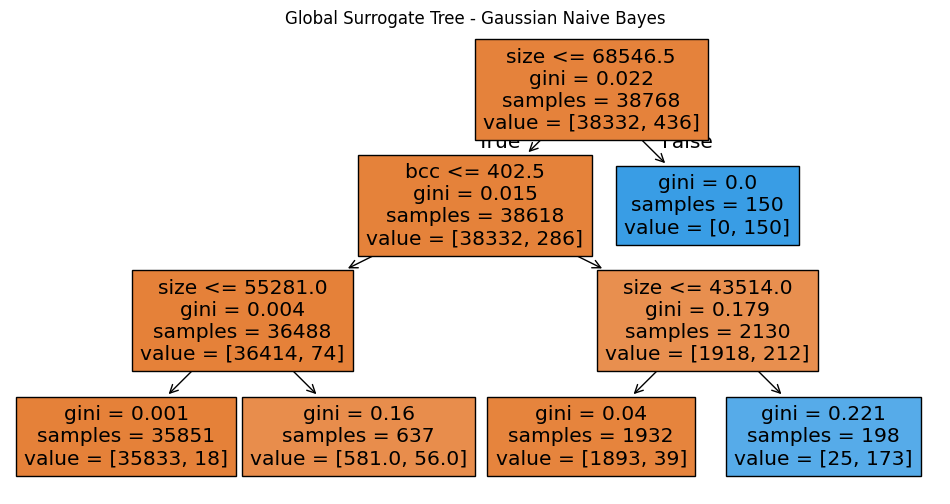

In [50]:
plt.figure(figsize=(12, 6))
tree.plot_tree(surrogate, feature_names=X_train.columns, filled=True)
plt.title("Global Surrogate Tree - Gaussian Naive Bayes")
plt.show()

This decision tree represents the way the Gaussian Naive Bayes model predicts, with **size** as the most important predictor. A **size below 68,546** would likely be benign but larger size with certain values of **bcc** could be malicious. The tree also records that the model is very confident when the case is benign (low gini impurity) but less confident when the case is a threat (high gini). These results align with the previous analyses, again confirming that **size** and **bcc** are the two most important variables for the model's decision, with the remaining variables adding no value. The tree presents the logic of the model in an easily interpretable format.